In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


First 5 Rows
   Student_ID Student_Name  Gender  Age      Branch  Graduation_Year  \
0        1001        Sneha    Male   20       Civil             2026   
1        1002        Kiran  Female   22         EEE             2026   
2        1003        Vikas  Female   24         EEE             2026   
3        1004        Sneha  Female   20  Mechanical             2026   
4        1005        Pavan    Male   21  Mechanical             2026   

   SSC_Percentage SSC_Board  HSC_Percentage HSC_Board  ... SQL_Skill  \
0            88.9     State            81.3     State  ...        45   
1            66.1     State            97.3     State  ...        46   
2            82.5     State            87.5     State  ...        45   
3            84.8     State            80.8     State  ...        57   
4            94.2     State            72.3     State  ...        81   

   DSA_Skill  Communication_Skills  Aptitude_Score  Coding_Test_Score  \
0         53                     5              

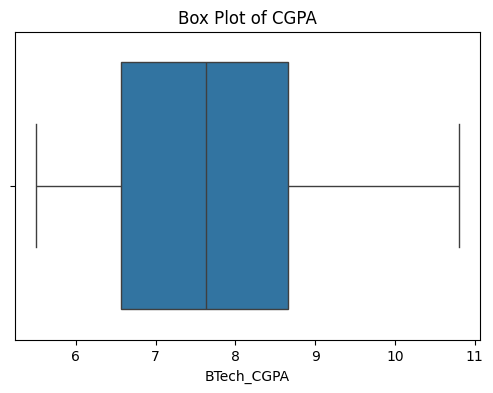


Accuracy
0.87

Accuracy Percentage
87.0

Confusion Matrix
[[196  20]
 [ 19  65]]


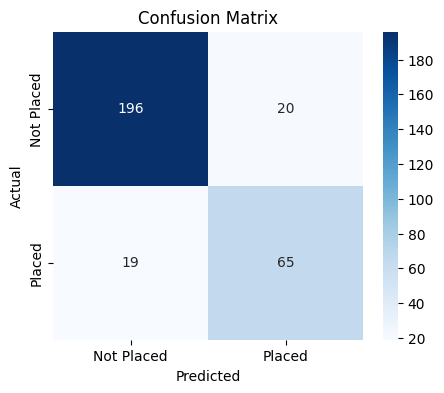

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML_Project/student_placement.csv')

print("First 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nInformation")
print(df.info())

print("\nSummary Statistics")
print(df.describe())


print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Rows")
print(df.duplicated().sum())


df = df.drop_duplicates()


df = df.dropna()


print("\nMissing Values After Cleaning")
print(df.isnull().sum())

print("\nDuplicate Rows After Cleaning")
print(df.duplicated().sum())

plt.figure(figsize=(6,4))
sns.boxplot(x=df["BTech_CGPA"])
plt.title("Box Plot of CGPA")
plt.show()

X = df[[
    "BTech_CGPA",
    "Projects_Count",
    "Internship_Count",
    "Coding_Test_Score"
]]

y = df["Placement_Status"]


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy")
print(accuracy)

print("\nAccuracy Percentage")
print(accuracy * 100)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Not Placed","Placed"],
            yticklabels=["Not Placed","Placed"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

df.to_csv("Cleaned_Student_Placement_Dataset.csv", index=False)